#### Tesla Deliveries ML Pipeline (2015–2025)


---

#### 1. Business Understanding

This project looks at Tesla's vehicle delivery data from 2015 to 2025. The aim is to find patterns in how many vehicles Tesla delivers each month across different regions and models, and then build a model that can predict future delivery numbers.

#### 1.1 Problem Statement

Tesla deliveries go up and down based on things like new model launches, factory capacity, region growth, and time of year. The question we want to answer is: can we use past delivery data and vehicle features to predict how many vehicles Tesla will deliver in future months?

#### 1.2 Goal

Build a machine learning model that predicts monthly Tesla deliveries by region and model, and also forecast total global deliveries for the next 4 quarters using time series methods.

#### 1.3 What We Are Predicting

We are predicting `Estimated_Deliveries` — the number of Tesla vehicles delivered in a given month, region, and model. This is a number (not a category), so we use regression models.

#### 2. Imports and Data Loading

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time series forecasting
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [49]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head(10)

Rows: 2640, Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [52]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


In [53]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)")

Duplicate rows: 0 (0.00%)


In [54]:
for col in ['Region', 'Model', 'Source_Type']:
    print(f"\n{col} unique values ({df[col].nunique()}):")
    print(df[col].value_counts())


Region unique values (4):
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model unique values (5):
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type unique values (3):
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


#### 3. Data Cleaning

#### 3.1 Missing Values

We first check for any missing or null values. Since the dataset has none, no imputation is needed. We also check that key numeric columns do not have unexpected zeros.

In [55]:
df_clean = df.copy()
assert df_clean.isnull().sum().sum() == 0, "Nulls found!"

for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']:
    zero_count = (df_clean[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

print("\nNo missing values — dataset is complete.")

Estimated_Deliveries: 0 zero values
Production_Units: 0 zero values
Avg_Price_USD: 0 zero values

No missing values — dataset is complete.


#### 3.2 Duplicate Removal

Each row should be unique for a given Year + Month + Region + Model combination. We check and remove any logical duplicates.

In [56]:
pk_cols = ['Year', 'Month', 'Region', 'Model']
logical_dupes = df_clean.duplicated(subset=pk_cols).sum()
print(f"Logical duplicates: {logical_dupes}")

if logical_dupes > 0:
    df_clean = df_clean.drop_duplicates(subset=pk_cols, keep='first')
    print(f"After removal: {df_clean.shape}")
else:
    print("No duplicates found.")

Logical duplicates: 0
No duplicates found.


#### 3.3 Outlier Check

We flag extreme outlier rows where delivery values are suspiciously high (more than 3 standard deviations from the mean). These are reviewed but not removed, as large delivery spikes can be genuine (e.g. end-of-quarter push or new factory ramp-up).

In [57]:
# Flag statistical outliers (> 3 std from mean) for inspection
delivery_mean = df_clean['Estimated_Deliveries'].mean()
delivery_std  = df_clean['Estimated_Deliveries'].std()

outliers = df_clean[
    (df_clean['Estimated_Deliveries'] > delivery_mean + 3 * delivery_std) |
    (df_clean['Estimated_Deliveries'] < delivery_mean - 3 * delivery_std)
]
print(f"Outlier rows (> 3σ): {len(outliers)}")
if len(outliers) > 0:
    print(outliers[['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries']].to_string(index=False))
else:
    print("No extreme outliers detected.")

Outlier rows (> 3σ): 4
 Year  Month        Region   Model  Estimated_Deliveries
 2015      3          Asia Model 3                 25410
 2015      6   Middle East Model Y                 22315
 2017     12 North America Model 3                 25704
 2022      5        Europe Model Y                 21772


#### 3.4 Date Column

We combine Year and Month into a single Date column so we can sort and work with the data in time order.

In [58]:
df_clean['Date'] = pd.to_datetime(df_clean[['Year', 'Month']].assign(Day=1))
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

print("Date range:", df_clean['Date'].min().date(), "to", df_clean['Date'].max().date())
df_clean[['Date', 'Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries']].head()

Date range: 2015-01-01 to 2025-12-01


,Date,Year,Month,Region,Model,Estimated_Deliveries
0,2015-01-01,2015,1,Asia,Model Y,12446
1,2015-01-01,2015,1,Middle East,Model 3,11446
2,2015-01-01,2015,1,Middle East,Cybertruck,8803
3,2015-01-01,2015,1,North America,Cybertruck,6367
4,2015-01-01,2015,1,Asia,Model 3,8795


#### 3.5 Data Checks

We check a few business rules to make sure the data makes sense: prices should be positive, months should be 1–12, and deliveries should not be wildly larger than production.

In [59]:
suspicious = df_clean[df_clean['Estimated_Deliveries'] > df_clean['Production_Units'] * 2]
print(f"Rows where deliveries > 2x production: {len(suspicious)}")

neg_prices = (df_clean['Avg_Price_USD'] <= 0).sum()
print(f"Rows with zero or negative price: {neg_prices}")

bad_months = ((df_clean['Month'] < 1) | (df_clean['Month'] > 12)).sum()
print(f"Rows with invalid month: {bad_months}")

print(f"\nFinal clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Rows where deliveries > 2x production: 0
Rows with zero or negative price: 0
Rows with invalid month: 0

Final clean dataset: 2640 rows, 13 columns


#### 4. Exploratory Data Analysis (EDA)

EDA is the process of visually and statistically exploring the data before building any model. The goal is to understand distributions, spot patterns, find outliers, and see which features matter. Each chart below answers a specific question about the data.

#### 4.1 Top Regions by Deliveries


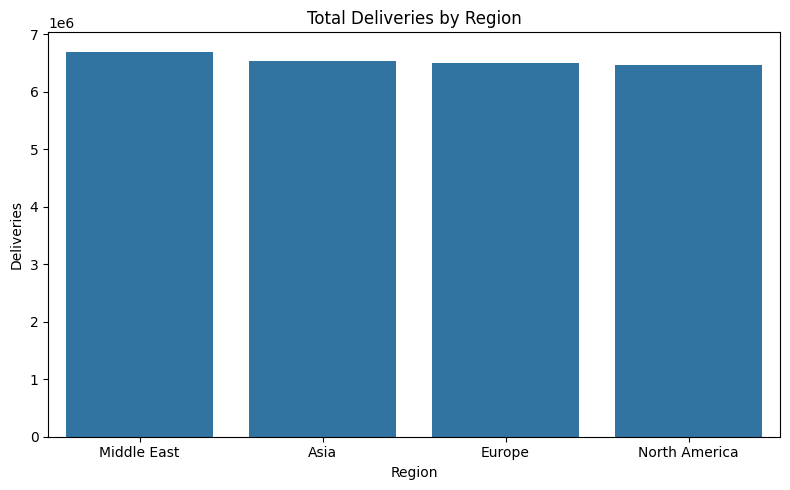

In [60]:
region_sales = (
    df.groupby('Region')['Estimated_Deliveries']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x='Region', y='Estimated_Deliveries')
plt.title('Total Deliveries by Region')
plt.ylabel('Deliveries')
plt.xlabel('Region')
plt.tight_layout()
plt.show()


#### 4.2 Model Popularity Analysis

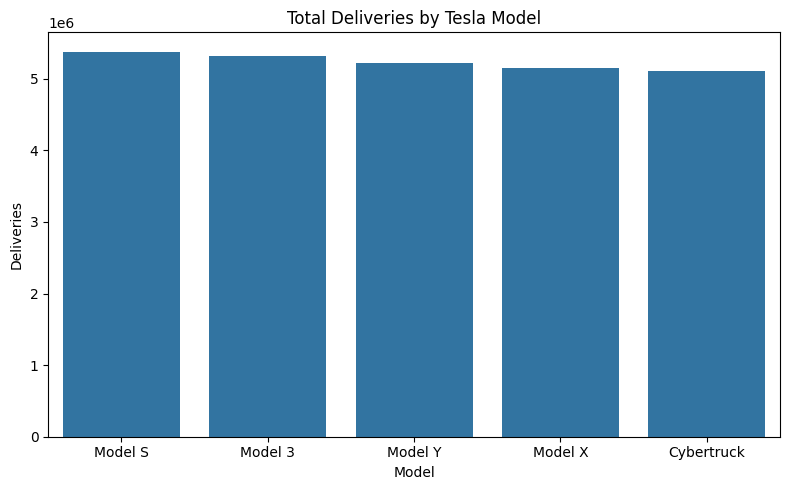

In [61]:
model_sales = (
    df.groupby('Model')['Estimated_Deliveries']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=model_sales, x='Model', y='Estimated_Deliveries')
plt.title('Total Deliveries by Tesla Model')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()


#### 4.3 Region Delivery Heatmap

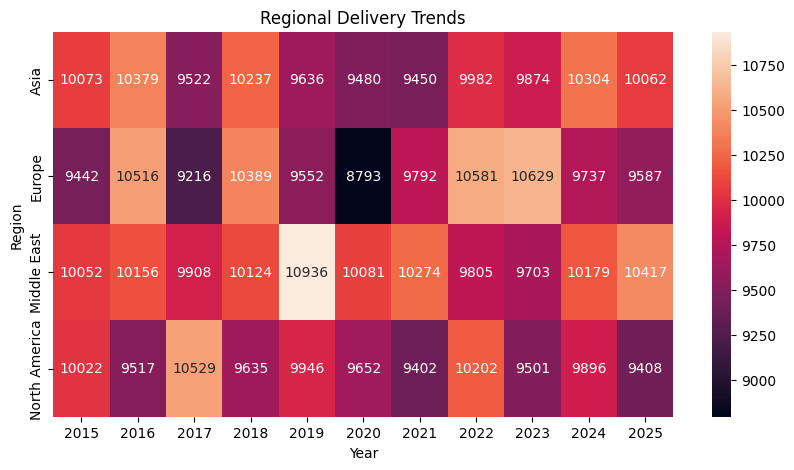

In [62]:
pivot = pd.pivot_table(
    df,
    values='Estimated_Deliveries',
    index='Region',
    columns='Year',
    aggfunc='mean'
)

plt.figure(figsize=(10,5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f'
)

plt.title('Regional Delivery Trends')
plt.show()

#### 4.4 Production Efficiency Analysis

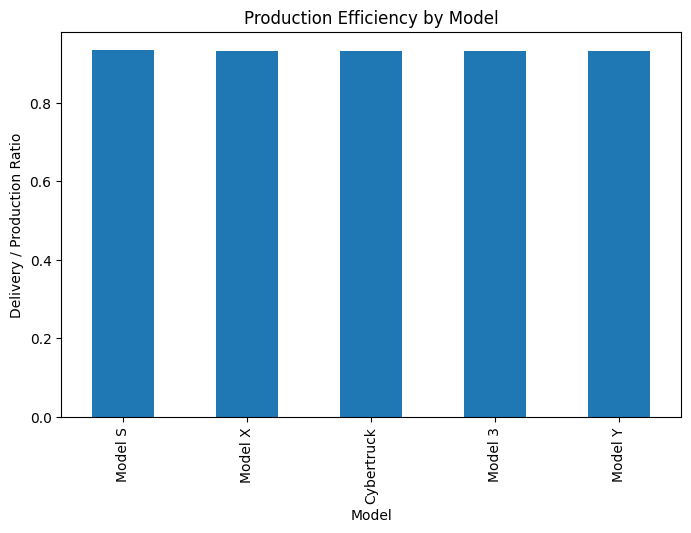

In [63]:
df['Production_Efficiency'] = (
    df['Estimated_Deliveries'] /
    df['Production_Units']
)

eff = (
    df.groupby('Model')['Production_Efficiency']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
eff.plot(kind='bar')

plt.title('Production Efficiency by Model')
plt.ylabel('Delivery / Production Ratio')
plt.show()

#### 4.5 Feature Correlation Matrix

Before engineering features, we examine how the raw numeric variables relate to each other and to the target. This guides feature selection and flags multicollinearity risks.

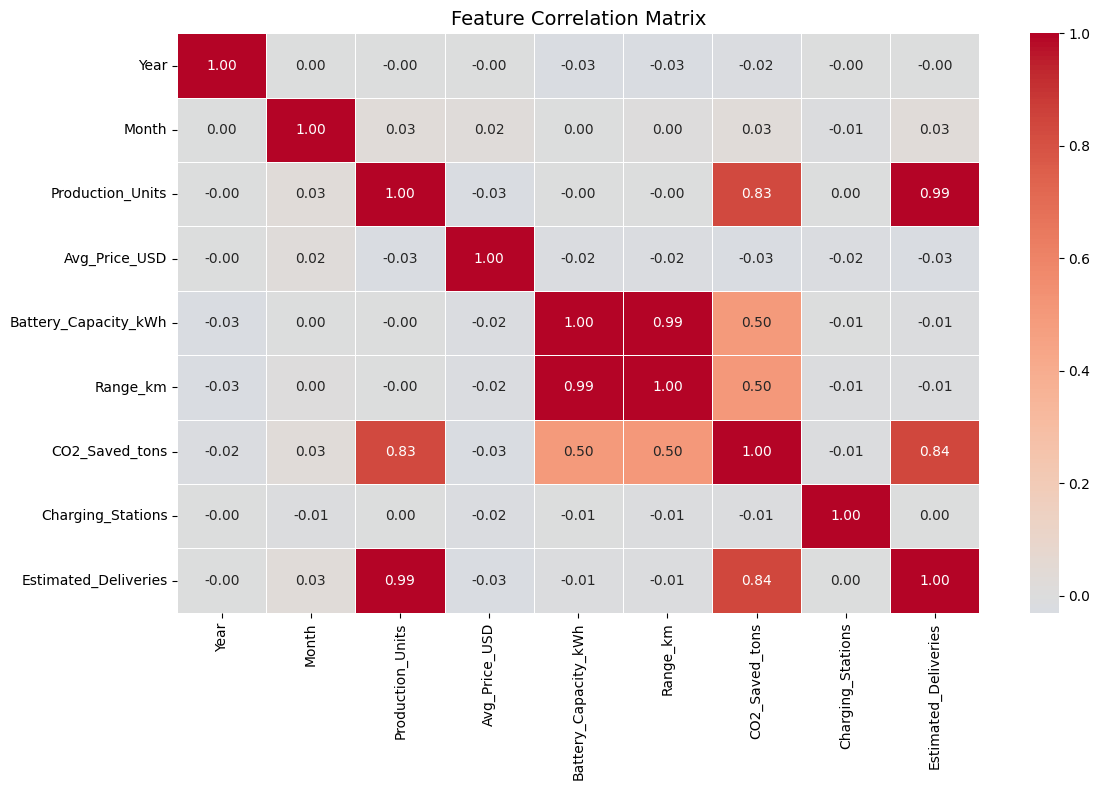

In [64]:
# Numerical Features Correlation Analysis

numerical_features = [
    'Year',
    'Month',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations',
    'Estimated_Deliveries'
]

corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

#### 5. Feature Engineering

Raw data columns alone are not enough for a good model. We create new columns that capture things like time of year, how deliveries have been trending, and recent momentum.

In [65]:
df_feat = df_clean.copy()
df_feat = df_feat.sort_values(['Region', 'Model', 'Date']).reset_index(drop=True)
print("Starting feature engineering...")

Starting feature engineering...


#### 5.1 Calendar Features

In [66]:
# Quarter number, Q4 flag, and quarter-end month flag
df_feat['Quarter'] = df_feat['Date'].dt.quarter
df_feat['Is_Q4'] = (df_feat['Quarter'] == 4).astype(int)
df_feat['Is_Quarter_End_Month'] = df_feat['Month'].isin([3, 6, 9, 12]).astype(int)

print("Created: Quarter, Is_Q4, Is_Quarter_End_Month")

Created: Quarter, Is_Q4, Is_Quarter_End_Month


#### 5.2 Lag Features

In [67]:
# Lag features: past delivery values for each Region-Model group
# We use Lag3 and Lag6 only — Lag1 and Lag2 were removed because they
# were too close to the target and caused R² to be unrealistically high (0.99)
group_cols = ['Region', 'Model']

for lag in [3, 6]:
    col_name = f'Deliveries_Lag{lag}'
    df_feat[col_name] = df_feat.groupby(group_cols)['Estimated_Deliveries'].shift(lag)
    print(f"Created: {col_name}")

Created: Deliveries_Lag3
Created: Deliveries_Lag6


Lag features tell the model what deliveries looked like 3 and 6 months ago for the same region and model. This captures medium-term momentum. We only use these past values (no future data), so there is no data leakage.

#### 5.3 Rolling Statistics

In [68]:
# 3-month and 6-month rolling average and standard deviation
# Using shift(1) before rolling to avoid using current month's value
for window in [3, 6]:
    df_feat[f'Rolling_Mean_{window}'] = (
        df_feat.groupby(group_cols)['Estimated_Deliveries']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df_feat[f'Rolling_Std_{window}'] = (
        df_feat.groupby(group_cols)['Estimated_Deliveries']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0))
    )
    print(f"Created: Rolling_Mean_{window}, Rolling_Std_{window}")

Created: Rolling_Mean_3, Rolling_Std_3
Created: Rolling_Mean_6, Rolling_Std_6


Rolling mean shows the recent average trend. Rolling standard deviation shows how much deliveries have been bouncing up and down recently. Both are calculated using only past data.

#### 5.4 Growth Rate Features

In [69]:
# Month-over-month and year-over-year growth
df_feat['MoM_Growth'] = (
    df_feat.groupby(group_cols)['Estimated_Deliveries']
    .pct_change(1).fillna(0).replace([np.inf, -np.inf], 0)
)

df_feat['YoY_Growth_Rate'] = (
    df_feat.groupby(group_cols)['Estimated_Deliveries']
    .pct_change(12).fillna(0).replace([np.inf, -np.inf], 0)
)

# Monthly price change
df_feat['Price_Change_MoM'] = (
    df_feat.groupby(group_cols)['Avg_Price_USD']
    .pct_change(1).fillna(0).replace([np.inf, -np.inf], 0)
)

new_features = [c for c in df_feat.columns if c not in df_clean.columns]
print(f"Total new features created: {len(new_features)}")
print("New features:", new_features)

Total new features created: 12
New features: ['Quarter', 'Is_Q4', 'Is_Quarter_End_Month', 'Deliveries_Lag3', 'Deliveries_Lag6', 'Rolling_Mean_3', 'Rolling_Std_3', 'Rolling_Mean_6', 'Rolling_Std_6', 'MoM_Growth', 'YoY_Growth_Rate', 'Price_Change_MoM']


In [70]:
before = len(df_feat)
df_feat = df_feat.dropna().reset_index(drop=True)
after = len(df_feat)
print(f"Rows dropped (NaN from lags): {before - after}")
print(f"Remaining rows: {after}")

Rows dropped (NaN from lags): 120
Remaining rows: 2520


#### 6. Data Preparation

Before training, we select the right features, handle any remaining NaN values with an imputer, and split data in time order.

#### 6.1 Feature Selection

We leave out `Production_Units` because it is almost the same as the target variable (correlation ~0.95). Keeping it would make R² look great but the model would not really be learning anything useful.

In [71]:
categorical_features = ['Region', 'Model']

numeric_features = [
    'Year', 'Month', 'Quarter', 'Is_Q4', 'Is_Quarter_End_Month',
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Charging_Stations',
    'Deliveries_Lag3', 'Deliveries_Lag6',
    'Rolling_Mean_3', 'Rolling_Std_3', 'Rolling_Mean_6', 'Rolling_Std_6',
    'MoM_Growth', 'YoY_Growth_Rate', 'Price_Change_MoM'
]

target = 'Estimated_Deliveries'

X = df_feat[categorical_features + numeric_features]
y = df_feat[target]

print(f"Features: {X.shape[1]} total ({len(categorical_features)} categorical, {len(numeric_features)} numeric)")
print(f"Samples : {X.shape[0]}")
print(f"NaN in X: {X.isnull().sum().sum()}")

Features: 21 total (2 categorical, 19 numeric)
Samples : 2520
NaN in X: 0


#### 6.2 Chronological Train-Test Split

In time series data, we must not randomly shuffle. We keep earlier data for training and later data for testing. This matches how the model would actually be used in real life — training on the past, predicting the future.

In [72]:
split_date = df_feat['Date'].max() - pd.DateOffset(months=12)

train_mask = df_feat['Date'] <= split_date
test_mask  = df_feat['Date'] >  split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape[0]} rows ({df_feat[train_mask]['Date'].min().date()} to {df_feat[train_mask]['Date'].max().date()})")
print(f"Test : {X_test.shape[0]} rows ({df_feat[test_mask]['Date'].min().date()} to {df_feat[test_mask]['Date'].max().date()})")
print(f"Test size: {len(X_test)/len(X)*100:.1f}% of data")

Train: 2280 rows (2015-07-01 to 2024-12-01)
Test : 240 rows (2025-01-01 to 2025-12-01)
Test size: 9.5% of data


#### 7. Machine Learning Pipeline

We use a sklearn Pipeline to keep preprocessing and modelling together. The preprocessor:
- Fills any remaining NaN values using the median (SimpleImputer)
- Scales numeric features to the same range (StandardScaler)
- Converts categorical columns to numbers (OneHotEncoder)

Everything is fit on training data only — no information from the test set leaks in.

In [73]:
# Numeric pipeline: impute NaNs then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# OneHotEncoder: sparse_output (sklearn >=1.2) or sparse (older)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Full preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', ohe, categorical_features)
])

# Quick check — pipeline works without errors
test_pipe = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])
test_pipe.fit(X_train, y_train)
test_pred = test_pipe.predict(X_test)

print("Pipeline check passed!")
print(f"First 5 predictions : {test_pred[:5].astype(int)}")
print(f"First 5 actual values: {y_test.values[:5]}")


Pipeline check passed!
First 5 predictions : [10362 12411  9165  7144  6520]
First 5 actual values: [10494 11891  8756  7653  5937]


#### 8. Regression Modelling

We train three regression models and compare them. Each model is evaluated on the test set using MAE, RMSE, and R².

In [74]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    mse  = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, preds)
    print(f"\n{'='*42}")
    print(f"  {name}")
    print(f"{'='*42}")
    print(f"  MAE  : {mae:>12,.1f}")
    print(f"  MSE  : {mse:>12,.1f}")
    print(f"  RMSE : {rmse:>12,.1f}")
    print(f"  R²   : {r2:>12.4f}")
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'pipeline': model}

results = []

#### 8.1 Linear Regression

The simplest model. It draws a straight line through the data to make predictions. No penalties on the coefficients.

In [75]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
results.append(evaluate_model('Linear Regression', lr_pipeline, X_train, y_train, X_test, y_test))


  Linear Regression
  MAE  :        614.2
  MSE  :    746,711.1
  RMSE :        864.1
  R²   :       0.9448


#### 8.2 Ridge Regression

Ridge adds a penalty (L2) that stops coefficients from getting too large. This helps when features are correlated with each other (like our lag features).

In [76]:
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
results.append(evaluate_model('Ridge Regression', ridge_pipeline, X_train, y_train, X_test, y_test))


  Ridge Regression
  MAE  :        615.1
  MSE  :    747,671.7
  RMSE :        864.7
  R²   :       0.9447


#### 8.3 Lasso Regression

Lasso adds a different penalty (L1) that can shrink some feature weights all the way to zero. This is useful for automatic feature selection — it drops features that are not helping.

In [77]:
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0, max_iter=10000))
])
results.append(evaluate_model('Lasso Regression', lasso_pipeline, X_train, y_train, X_test, y_test))


  Lasso Regression
  MAE  :        615.6
  MSE  :    746,668.0
  RMSE :        864.1
  R²   :       0.9448


#### 8.4 Actual vs Predicted Plot

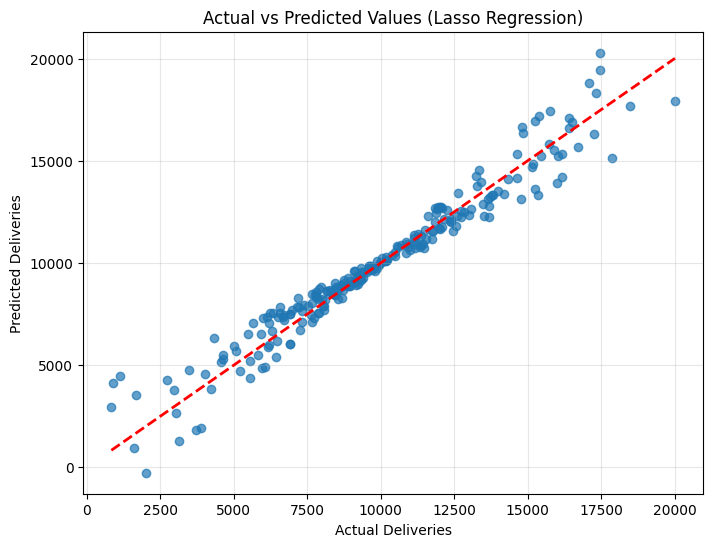

In [78]:
# Fit Lasso Model
lasso_pipeline.fit(X_train, y_train)

# Predictions
y_pred = lasso_pipeline.predict(X_test)

# Actual vs Predicted Plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted Values (Lasso Regression)')
plt.grid(alpha=0.3)

plt.show()

#### 9. Cross Validation with TimeSeriesSplit

Standard K-Fold cross validation randomly mixes past and future data, which is not suitable for time series problems. TimeSeriesSplit uses a Chronological approach — it always trains on earlier data and validates on later data, preserving the natural time order.

In [79]:
tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit Cross-Validation Results:")
print("-" * 70)
for name, pipe in [('Linear Regression', lr_pipeline),
                   ('Ridge Regression',  ridge_pipeline),
                   ('Lasso Regression',  lasso_pipeline)]:
    cv = cross_val_score(pipe, X_train, y_train, cv=tscv, scoring='r2')
    print(f"{name:22s}  Fold R²: {np.round(cv, 3)}  Mean={cv.mean():.4f}  Std={cv.std():.4f}")

TimeSeriesSplit Cross-Validation Results:
----------------------------------------------------------------------
Linear Regression       Fold R²: [0.941 0.938 0.943 0.945 0.95 ]  Mean=0.9433  Std=0.0040
Ridge Regression        Fold R²: [0.941 0.938 0.943 0.945 0.95 ]  Mean=0.9434  Std=0.0040
Lasso Regression        Fold R²: [0.941 0.938 0.943 0.946 0.95 ]  Mean=0.9435  Std=0.0041


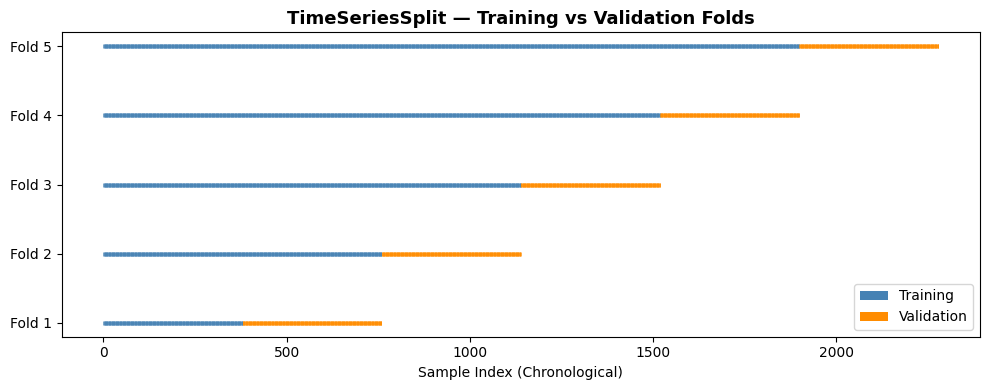

In [80]:
fig, ax = plt.subplots(figsize=(10, 4))
X_arr = X_train.values
for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_arr)):
    ax.scatter(tr_idx,  [fold_idx+0.5]*len(tr_idx),  c='steelblue',  marker='|', s=10, linewidths=0.5)
    ax.scatter(val_idx, [fold_idx+0.5]*len(val_idx), c='darkorange', marker='|', s=10, linewidths=0.5)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='steelblue', label='Training'),
                   Patch(facecolor='darkorange', label='Validation')], loc='lower right')
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel("Sample Index (Chronological)")
ax.set_title("TimeSeriesSplit — Training vs Validation Folds", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### 10. Hyperparameter Tuning

We search for the best regularisation strength (alpha) for Ridge and Lasso using GridSearchCV. We still use TimeSeriesSplit so the search respects time order.

In [81]:
tscv_tune = TimeSeriesSplit(n_splits=5)

print("Tuning Ridge...")
grid_ridge = GridSearchCV(
    ridge_pipeline,
    {'regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 500.0]},
    cv=tscv_tune, scoring='r2', n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
print(f"  Best alpha: {grid_ridge.best_params_}  CV R²={grid_ridge.best_score_:.4f}")

print("\nTuning Lasso...")
grid_lasso = GridSearchCV(
    lasso_pipeline,
    {'regressor__alpha': [0.1, 1.0, 5.0, 10.0, 50.0]},
    cv=tscv_tune, scoring='r2', n_jobs=-1
)
grid_lasso.fit(X_train, y_train)
print(f"  Best alpha: {grid_lasso.best_params_}  CV R²={grid_lasso.best_score_:.4f}")

Tuning Ridge...
  Best alpha: {'regressor__alpha': 10.0}  CV R²=0.9436

Tuning Lasso...
  Best alpha: {'regressor__alpha': 50.0}  CV R²=0.9443


In [82]:
print("Tuned Model Performance on Test Set:")
print("-" * 55)
for name, model in [('Ridge (Tuned)', grid_ridge.best_estimator_),
                    ('Lasso (Tuned)', grid_lasso.best_estimator_)]:
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    print(f"  {name:20s}  MAE={mae:,.1f}  RMSE={rmse:,.1f}  R²={r2:.4f}")
    results.append({'Model': name, 'MAE': mae, 'MSE': mean_squared_error(y_test, preds),
                    'RMSE': rmse, 'R2': r2, 'pipeline': model})

Tuned Model Performance on Test Set:
-------------------------------------------------------
  Ridge (Tuned)         MAE=620.8  RMSE=868.6  R²=0.9442
  Lasso (Tuned)         MAE=606.3  RMSE=859.4  R²=0.9454


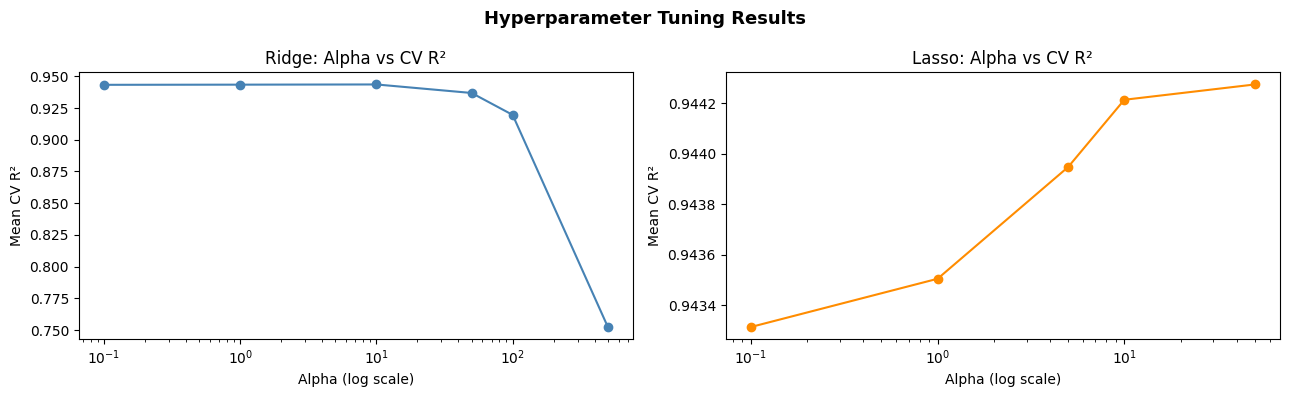

In [83]:
# Alpha tuning curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ridge_res = pd.DataFrame(grid_ridge.cv_results_)
lasso_res = pd.DataFrame(grid_lasso.cv_results_)

axes[0].plot(ridge_res['param_regressor__alpha'], ridge_res['mean_test_score'], marker='o', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_title("Ridge: Alpha vs CV R²")
axes[0].set_xlabel("Alpha (log scale)")
axes[0].set_ylabel("Mean CV R²")

axes[1].plot(lasso_res['param_regressor__alpha'], lasso_res['mean_test_score'], marker='o', color='darkorange')
axes[1].set_xscale('log')
axes[1].set_title("Lasso: Alpha vs CV R²")
axes[1].set_xlabel("Alpha (log scale)")
axes[1].set_ylabel("Mean CV R²")

plt.suptitle("Hyperparameter Tuning Results", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 11. Model Comparison

We now compare all trained models side by side.

In [84]:
comp_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pipeline'} for r in results])
comp_df = comp_df.sort_values('R2', ascending=False).reset_index(drop=True)
comp_df.index += 1
print("Model Comparison Table:")
print(comp_df[['Model', 'MAE', 'RMSE', 'R2']].to_string(
    float_format=lambda x: f'{x:,.2f}' if abs(x) > 1 else f'{x:.4f}'))

Model Comparison Table:
               Model    MAE   RMSE     R2
1      Lasso (Tuned) 606.33 859.36 0.9454
2   Lasso Regression 615.58 864.10 0.9448
3  Linear Regression 614.22 864.12 0.9448
4   Ridge Regression 615.09 864.68 0.9447
5      Ridge (Tuned) 620.77 868.63 0.9442


In [85]:
# Best R² (Higher is Better)
best_r2 = comp_df.loc[comp_df['R2'].idxmax()]

# Best MAE (Lower is Better)
best_mae = comp_df.loc[comp_df['MAE'].idxmin()]

# Best RMSE (Lower is Better)
best_rmse = comp_df.loc[comp_df['RMSE'].idxmin()]

print("===== Best Models =====")
print(f"Best R²   : {best_r2['Model']} ({best_r2['R2']:.4f})")
print(f"Best MAE  : {best_mae['Model']} ({best_mae['MAE']:.2f})")
print(f"Best RMSE : {best_rmse['Model']} ({best_rmse['RMSE']:.2f})")

===== Best Models =====
Best R²   : Lasso (Tuned) (0.9454)
Best MAE  : Lasso (Tuned) (606.33)
Best RMSE : Lasso (Tuned) (859.36)


### Best Model

In [86]:
best_row = comp_df.iloc[0]
best_name = best_row['Model']
best_pipeline = [r['pipeline'] for r in results if r['Model'] == best_name][0]

print(f"Best model  : {best_name}")
print(f"R²          : {best_row['R2']:.4f}")
print(f"RMSE        : {best_row['RMSE']:,.1f} vehicles")
print(f"MAE         : {best_row['MAE']:,.1f} vehicles")

Best model  : Lasso (Tuned)
R²          : 0.9454
RMSE        : 859.4 vehicles
MAE         : 606.3 vehicles


#### 12. Time Series Analysis

Before we build time series forecasting models, we study the behaviour of the delivery data over time. We look at trend, seasonality, and whether the series is stationary.

In [87]:
# Aggregate to monthly global total
ts = (
    df_clean.set_index('Date')['Estimated_Deliveries']
    .resample('MS').sum()
)

print(f"Monthly time series: {len(ts)} observations")
print(f"Range: {ts.index[0].date()} to {ts.index[-1].date()}")
ts.head()


Monthly time series: 132 observations
Range: 2015-01-01 to 2025-12-01


Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Freq: MS, Name: Estimated_Deliveries, dtype: int64

#### 12.1 Trend and Moving Averages

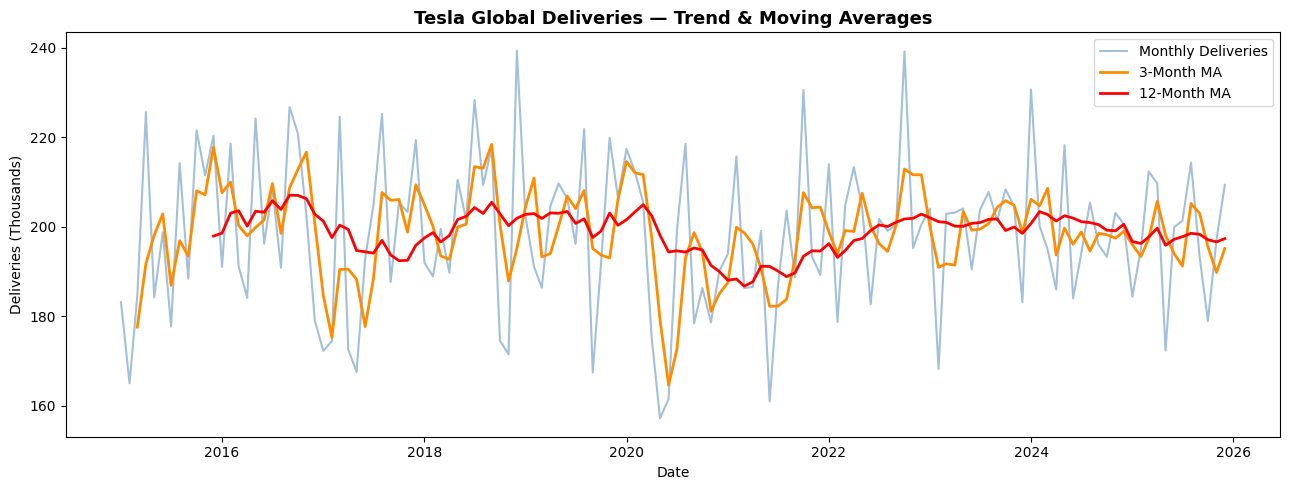

In [88]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values / 1e3, label='Monthly Deliveries', color='steelblue', alpha=0.5)
ax.plot(ts.index, ts.rolling(3).mean().values / 1e3, label='3-Month MA', color='darkorange', linewidth=2)
ax.plot(ts.index, ts.rolling(12).mean().values / 1e3, label='12-Month MA', color='red', linewidth=2)
ax.set_title("Tesla Global Deliveries — Trend & Moving Averages", fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Deliveries (Thousands)")
ax.legend()
plt.tight_layout()
plt.show()

The 12-month moving average shows a clear upward trend from 2015 onwards. The 3-month average captures the quarterly peaks. The series is not stationary — the average delivery level keeps rising over time.

#### 12.2 Seasonal Decomposition

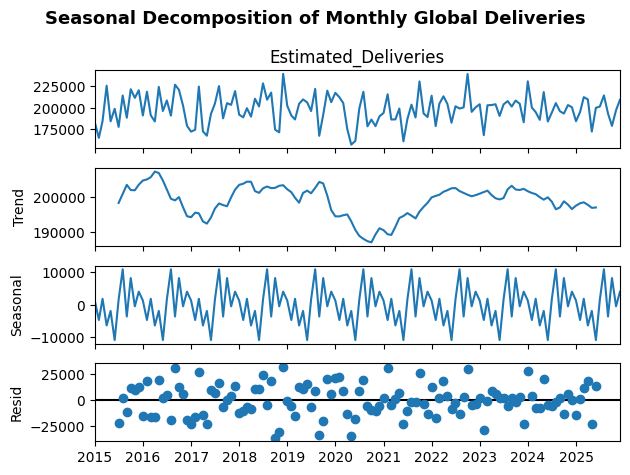

In [89]:
# Seasonal decomposition on aggregated monthly global delivery series
result = seasonal_decompose(
    ts,
    model='additive',
    period=12
)

result.plot()
plt.suptitle('Seasonal Decomposition of Monthly Global Deliveries', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The decomposition splits the series into three parts:
- **Trend**: the long-term growth direction
- **Seasonal**: the repeating yearly pattern (Q4 spikes every year)
- **Residual**: the leftover noise that neither trend nor season explains

#### 12.3 Stationarity Test (ADF Test)

In [90]:
def adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"\nADF Test — {label}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print("  Result: STATIONARY (p < 0.05)")
    else:
        print("  Result: NOT STATIONARY (p >= 0.05) — differencing needed")

adf_test(ts, "Original Series")
adf_test(ts.diff(), "First-Differenced Series")


ADF Test — Original Series
  ADF Statistic : -8.8810
  p-value       : 0.0000
  Result: STATIONARY (p < 0.05)

ADF Test — First-Differenced Series
  ADF Statistic : -7.0101
  p-value       : 0.0000
  Result: STATIONARY (p < 0.05)


The ADF test indicates that the original delivery series is stationary (p < 0.05). The first-differenced series is also stationary. Therefore, the dataset does not show strong evidence of a unit root, and the series is suitable for time-series analysis.


#### 12.4 ACF and PACF Analysis

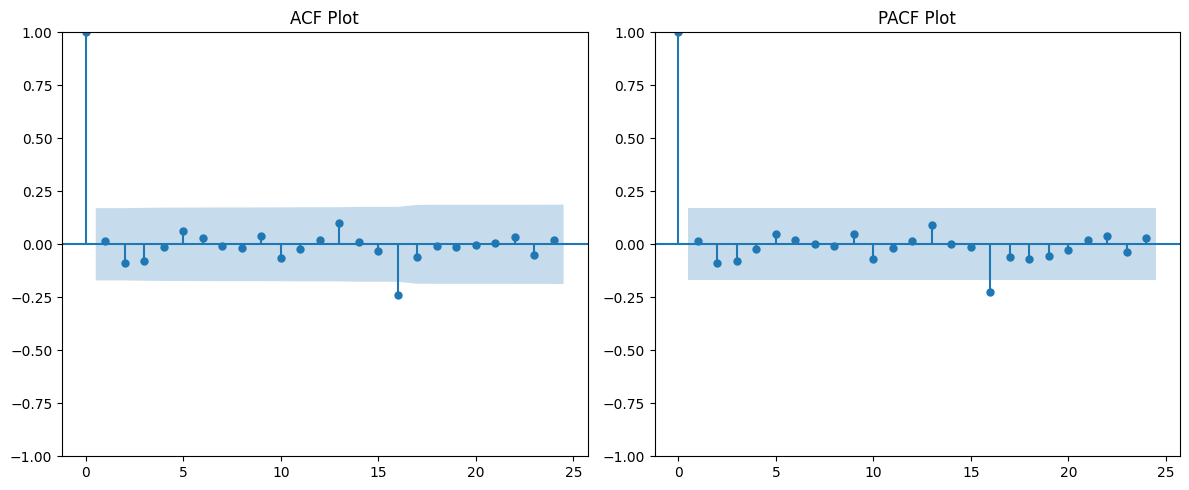

In [91]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

max_lags = min(24, len(ts) // 2 - 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(ts, lags=max_lags, ax=plt.gca())
plt.title("ACF Plot")

plt.subplot(1,2,2)
plot_pacf(ts, lags=max_lags, ax=plt.gca())
plt.title("PACF Plot")

plt.tight_layout()
plt.show()


#### 13. Time Series Forecasting Models

We use two dedicated time series forecasting methods on quarterly aggregated data. These are different from the regression models — they work directly on the sequence of delivery totals over time, without needing feature columns.

We use quarterly data because that is how Tesla officially reports deliveries, and it is more stable than monthly numbers.

In [92]:
# Build quarterly global delivery time series
quarterly_ts = (
    df_clean.set_index('Date')['Estimated_Deliveries']
    .resample('QS').sum()
)

print(f"Quarterly time series: {len(quarterly_ts)} quarters")
print(f"Range: {quarterly_ts.index[0].date()} to {quarterly_ts.index[-1].date()}")
print("\nLast 8 quarters:")
print(quarterly_ts.tail(8))


Quarterly time series: 44 quarters
Range: 2015-01-01 to 2025-10-01

Last 8 quarters:
Date
2024-01-01    625851
2024-04-01    588328
2024-07-01    595658
2024-10-01    597062
2025-01-01    591840
2025-04-01    582037
2025-07-01    609084
2025-10-01    585501
Freq: QS-JAN, Name: Estimated_Deliveries, dtype: int64


In [93]:
# Train-Test Split (Time Series)

qts_train = quarterly_ts.iloc[:-4]
qts_test  = quarterly_ts.iloc[-4:]

print("=" * 50)
print("TIME SERIES TRAIN-TEST SPLIT")
print("=" * 50)

print(f"Training Samples : {len(qts_train)} quarters")
print(f"Testing Samples  : {len(qts_test)} quarters")

print("\nForecast Evaluation Period:")
print("-" * 30)

for date, value in qts_test.items():
    quarter = (date.month - 1) // 3 + 1
    print(f"{date.year} Q{quarter} : {value:,.0f} deliveries")

TIME SERIES TRAIN-TEST SPLIT
Training Samples : 40 quarters
Testing Samples  : 4 quarters

Forecast Evaluation Period:
------------------------------
2025 Q1 : 591,840 deliveries
2025 Q2 : 582,037 deliveries
2025 Q3 : 609,084 deliveries
2025 Q4 : 585,501 deliveries


#### 13.1 Holt-Winters Exponential Smoothing

Holt-Winters is a classic time series method that handles both trend and seasonality. It works by giving more weight to recent data while still using older data.

Three components:
- **Level**: the current smoothed value
- **Trend**: the direction the series is moving
- **Seasonal**: the repeating quarterly pattern

We use additive seasonality because the seasonal peaks are roughly the same size throughout (not growing proportionally).

In [94]:
hw_model = ExponentialSmoothing(
    qts_train,
    trend='add',
    seasonal='add',
    seasonal_periods=4   # 4 quarters per year
)
hw_fit = hw_model.fit(optimized=True)
hw_pred = hw_fit.forecast(4)

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

hw_mae  = mean_absolute_error(qts_test, hw_pred)
hw_rmse = np.sqrt(mean_squared_error(qts_test, hw_pred))
hw_mape = mape(qts_test.values, hw_pred.values)

print("Holt-Winters Results on Last 4 Quarters:")
print("-" * 55)
print(f"  MAE  : {hw_mae:>10,.0f} vehicles")
print(f"  RMSE : {hw_rmse:>10,.0f} vehicles")
print(f"  MAPE : {hw_mape:>10.2f}%")
print("\nQuarter-by-Quarter:")
for d, actual, pred in zip(qts_test.index, qts_test.values, hw_pred.values):
    q = (d.month - 1) // 3 + 1
    err = abs(actual - pred) / actual * 100
    print(f"  {d.year} Q{q}: Actual={actual:,.0f}  Predicted={pred:,.0f}  Error={err:.1f}%")

Holt-Winters Results on Last 4 Quarters:
-------------------------------------------------------
  MAE  :     14,022 vehicles
  RMSE :     16,835 vehicles
  MAPE :       2.37%

Quarter-by-Quarter:
  2025 Q1: Actual=591,840  Predicted=577,418  Error=2.4%
  2025 Q2: Actual=582,037  Predicted=585,961  Error=0.7%
  2025 Q3: Actual=609,084  Predicted=618,005  Error=1.5%
  2025 Q4: Actual=585,501  Predicted=614,323  Error=4.9%


**Best Regression Model**

Lasso (Tuned) achieved the best overall performance with:
• R² = 0.9454
• RMSE = 859.4
• MAE = 606.3

Therefore, Lasso (Tuned) was selected as the final regression model.

**Next Steps:**

- Add external variables to the regression model (interest rates, competitor sales, EV incentives)
- Try tree-based models like Random Forest or XGBoost for potentially higher R²
- Use SARIMA order selection (auto-ARIMA) to automatically find better parameters
- Retrain models every quarter as new data arrives